In [1]:
# ============================================================
# Liver leave-one-patient-out validation for DynML
# Models: DynML, direct ridge, persistence
# Metrics: Pearson r, RMSE, MAE, R2, calibration slope/intercept
# ============================================================

import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# Configuration
# ============================================================

patient_ids = list(range(1, 13))
patient_folder_template = "Patient{}"
cluster_pattern = "cluster{}.csv"
n_clusters_expected = 15

timepoint_names = [
    "Before Surgery", "5 Minutes", "30 Minutes", "60 Minutes",
    "120 Minutes", "1 Day", "2 Days", "3 Days",
    "4 Days", "10 Days", "3 Months", "6 Months", "1 Year"
]

transitions_of_interest = [
    ("5 Minutes", "1 Day"),
    ("1 Day", "3 Months")
]

timepoint_to_idx = {name: i for i, name in enumerate(timepoint_names)}
T = len(timepoint_names)

# Panel generation
n_train_panels = 6000
n_test_panels = 1000

# DynML settings
N = 150
t_initial, t_final = 0, 4
ridge_alpha_readout = 1e-6
ridge_alpha_baseline = 1.0

base_seed = 46

# ============================================================
# Utility functions
# ============================================================

def clean_float(x):
    x = str(x).replace("[", "").replace("]", "")
    return float(x)


def load_patient_clusters(patient_id):
    """
    Load all cluster CSV files for one patient.
    Returns a list of DataFrames, one per cluster.
    """
    patient_folder = patient_folder_template.format(patient_id)
    clusters = []

    for c in range(1, n_clusters_expected + 1):
        fname = os.path.join(patient_folder, cluster_pattern.format(c))

        if not os.path.exists(fname):
            raise FileNotFoundError(f"Missing file: {fname}")

        df = pd.read_csv(fname, header=None)
        clusters.append(df)

    return clusters


def load_all_patients(patient_ids):
    """
    Load cluster files for all patients.
    """
    all_patient_clusters = {}

    for pid in patient_ids:
        print(f"Loading Patient {pid}")
        all_patient_clusters[pid] = load_patient_clusters(pid)

    return all_patient_clusters


def sample_one_panel_from_patient(patient_clusters, rng):
    """
    Sample one gene from each cluster for a single patient.

    Returns
    -------
    gene_matrix : array, shape (15, 13)
        One sampled gene per cluster across all timepoints.
    gene_names : list
        Sampled gene names.
    """
    gene_matrix = np.zeros((n_clusters_expected, T), dtype=float)
    gene_names = []

    for ci, df in enumerate(patient_clusters):
        row_idx = rng.integers(0, df.shape[0])
        row = df.iloc[row_idx, :].values

        gene_names.append(str(row[0]))

        expr_vals = np.array(
            [clean_float(v) for v in row[1:1 + T]],
            dtype=float
        )

        gene_matrix[ci, :] = expr_vals

    return gene_matrix, gene_names


def generate_panels_from_patient_set(
    all_patient_clusters,
    allowed_patient_ids,
    n_panels,
    seed
):
    """
    Generate synthetic panels from a set of allowed patients.

    For training folds, allowed_patient_ids should exclude the held-out patient.
    For testing folds, allowed_patient_ids should contain only the held-out patient.
    """
    rng = np.random.default_rng(seed)

    all_samples = np.zeros((n_panels, n_clusters_expected, T), dtype=float)
    panel_patient_ids = []
    panel_gene_names = []

    for i in range(n_panels):
        pid = int(rng.choice(allowed_patient_ids))
        patient_clusters = all_patient_clusters[pid]

        gene_matrix, gene_names = sample_one_panel_from_patient(
            patient_clusters=patient_clusters,
            rng=rng
        )

        all_samples[i] = gene_matrix
        panel_patient_ids.append(pid)
        panel_gene_names.append(gene_names)

    return all_samples, panel_patient_ids, panel_gene_names


def build_transition_matrices(all_samples):
    """
    Build X and Y matrices for selected transitions.

    all_samples shape:
        (n_panels, n_clusters, T)

    Returns
    -------
    X : array, shape (n_clusters * n_transitions, n_panels)
    Y : array, shape (n_clusters * n_transitions, n_panels)

    Row order:
        cluster 1 transition 1
        cluster 1 transition 2
        cluster 2 transition 1
        cluster 2 transition 2
        ...
    """
    X_rows = []
    Y_rows = []

    for c in range(n_clusters_expected):
        block = all_samples[:, c, :].T  # shape (T, n_panels)

        for from_name, to_name in transitions_of_interest:
            t_from = timepoint_to_idx[from_name]
            t_to = timepoint_to_idx[to_name]

            X_rows.append(block[t_from, :])
            Y_rows.append(block[t_to, :])

    X = np.asarray(X_rows, dtype=float)
    Y = np.asarray(Y_rows, dtype=float)

    return X, Y


def transition_row_indices(t_idx):
    """
    Get row indices for one transition in X/Y.

    Because rows are ordered as:
        cluster 1 trans 1, cluster 1 trans 2,
        cluster 2 trans 1, cluster 2 trans 2, ...
    """
    n_transitions = len(transitions_of_interest)
    return np.arange(t_idx, n_clusters_expected * n_transitions, n_transitions)


def compute_regression_metrics(y_true, y_pred):
    """
    Compute metrics on flattened arrays.
    """
    yt = np.asarray(y_true).reshape(-1)
    yp = np.asarray(y_pred).reshape(-1)

    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)

    if np.std(yt) > 0 and np.std(yp) > 0:
        pearson_r, pearson_p = pearsonr(yt, yp)
    else:
        pearson_r, pearson_p = np.nan, np.nan

    if np.std(yt) > 0:
        calibration_slope, calibration_intercept = np.polyfit(yt, yp, 1)
    else:
        calibration_slope, calibration_intercept = np.nan, np.nan

    return {
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "calibration_slope": calibration_slope,
        "calibration_intercept": calibration_intercept
    }


# ============================================================
# DynML reservoir functions
# ============================================================

def make_lorenz_params(N, rng):
    param_range_reservoir = [
        (9.9, 10.1),
        (27.9, 28.1),
        (2.65, 2.70)
    ]

    reservoir_params = np.array([
        [rng.uniform(low, high) for low, high in param_range_reservoir]
        + [rng.uniform(1, 8)]
        for _ in range(N)
    ])

    return reservoir_params


def lorenz_system(t, Xvec, params):
    X = Xvec.reshape(N, 3)

    sigma = params[:, 0]
    rho = params[:, 1]
    beta = params[:, 2]
    tau = params[:, 3]

    dxdt = sigma * (X[:, 1] - X[:, 0]) / tau
    dydt = (X[:, 0] * (rho - X[:, 2]) - X[:, 1]) / tau
    dzdt = (X[:, 0] * X[:, 1] - beta * X[:, 2]) / tau

    return np.stack([dxdt, dydt, dzdt], axis=1).flatten()


def compute_reservoir_features(X_norm, seed):
    """
    Generate final reservoir states for all samples.

    X_norm shape:
        (num_input_features, num_samples)

    Returns
    -------
    phi : array, shape (3N, num_samples)
    """
    rng = np.random.default_rng(seed)

    M = X_norm.shape[0]
    D = X_norm.shape[1]

    reservoir_params = make_lorenz_params(N, rng)
    R = rng.uniform(-1.0, 1.0, size=(3 * N, M))

    phi = np.zeros((3 * N, D), dtype=float)

    for i in range(D):
        if i % 500 == 0:
            print(f"    reservoir sample {i + 1}/{D}")

        init = R @ X_norm[:, i]

        sol = solve_ivp(
            lorenz_system,
            (t_initial, t_final),
            init,
            t_eval=[t_final],
            args=(reservoir_params,),
            rtol=1e-6,
            atol=1e-9
        )

        if not sol.success:
            raise RuntimeError(f"Reservoir integration failed for sample {i}: {sol.message}")

        phi[:, i] = sol.y[:, -1]

    return phi


# ============================================================
# Load data
# ============================================================

all_patient_clusters = load_all_patients(patient_ids)

# ============================================================
# Leave-one-patient-out validation
# ============================================================

all_results = []

start_time = time.time()

for held_out_patient in patient_ids:

    print("\n" + "=" * 90)
    print(f"Leave-one-patient-out fold: held-out Patient {held_out_patient}")
    print("=" * 90)

    train_patients = [pid for pid in patient_ids if pid != held_out_patient]
    test_patients = [held_out_patient]

    fold_seed = base_seed + held_out_patient

    # --------------------------------------------------------
    # Generate train panels only from training patients
    # Generate test panels only from held-out patient
    # --------------------------------------------------------
    train_samples, train_panel_patient_ids, _ = generate_panels_from_patient_set(
        all_patient_clusters=all_patient_clusters,
        allowed_patient_ids=train_patients,
        n_panels=n_train_panels,
        seed=fold_seed
    )

    test_samples, test_panel_patient_ids, _ = generate_panels_from_patient_set(
        all_patient_clusters=all_patient_clusters,
        allowed_patient_ids=test_patients,
        n_panels=n_test_panels,
        seed=fold_seed + 10000
    )

    print("Train samples:", train_samples.shape)
    print("Test samples:", test_samples.shape)

    X_train_raw, Y_train_raw = build_transition_matrices(train_samples)
    X_test_raw, Y_test_raw = build_transition_matrices(test_samples)

    # --------------------------------------------------------
    # Standardize using training data only
    # --------------------------------------------------------
    scaler_X = StandardScaler()
    scaler_Y = StandardScaler()

    X_train_norm = scaler_X.fit_transform(X_train_raw.T).T
    X_test_norm = scaler_X.transform(X_test_raw.T).T

    Y_train_norm = scaler_Y.fit_transform(Y_train_raw.T).T
    Y_test_norm = scaler_Y.transform(Y_test_raw.T).T

    # --------------------------------------------------------
    # Baseline 1: direct ridge regression
    # --------------------------------------------------------
    ridge_baseline = Ridge(alpha=ridge_alpha_baseline, fit_intercept=True)
    ridge_baseline.fit(X_train_norm.T, Y_train_norm.T)

    ridge_pred_norm = ridge_baseline.predict(X_test_norm.T).T
    ridge_pred = scaler_Y.inverse_transform(ridge_pred_norm.T).T

    # --------------------------------------------------------
    # Baseline 2: persistence
    # Prediction = expression at current transition time
    # --------------------------------------------------------
    persistence_pred = X_test_raw.copy()

    # --------------------------------------------------------
    # DynML
    # --------------------------------------------------------
    X_all_norm = np.hstack([X_train_norm, X_test_norm])

    phi_all = compute_reservoir_features(
        X_norm=X_all_norm,
        seed=fold_seed + 20000
    )

    phi_train = phi_all[:, :X_train_norm.shape[1]].T
    phi_test = phi_all[:, X_train_norm.shape[1]:].T

    readout = Ridge(alpha=ridge_alpha_readout, fit_intercept=True)
    readout.fit(phi_train, Y_train_norm.T)

    dynml_pred_norm = readout.predict(phi_test).T
    dynml_pred = scaler_Y.inverse_transform(dynml_pred_norm.T).T

    # --------------------------------------------------------
    # Metrics per transition and model
    # --------------------------------------------------------
    predictions = {
        "DynML": dynml_pred,
        "Direct ridge": ridge_pred,
        "Persistence": persistence_pred
    }

    for model_name, pred in predictions.items():

        # Overall metrics across both transitions
        overall_metrics = compute_regression_metrics(Y_test_raw, pred)

        all_results.append({
            "held_out_patient": held_out_patient,
            "transition": "overall",
            "model": model_name,
            "n_train_panels": n_train_panels,
            "n_test_panels": n_test_panels,
            "N": N if model_name == "DynML" else 0,
            **overall_metrics
        })

        # Transition-specific metrics
        for t_idx, (from_name, to_name) in enumerate(transitions_of_interest):
            rows_idx = transition_row_indices(t_idx)

            y_true_t = Y_test_raw[rows_idx, :]
            y_pred_t = pred[rows_idx, :]

            metrics_t = compute_regression_metrics(y_true_t, y_pred_t)

            all_results.append({
                "held_out_patient": held_out_patient,
                "transition": f"{from_name} -> {to_name}",
                "model": model_name,
                "n_train_panels": n_train_panels,
                "n_test_panels": n_test_panels,
                "N": N if model_name == "DynML" else 0,
                **metrics_t
            })

results_df = pd.DataFrame(all_results)

results_df.to_csv(
    "liver_leave_one_patient_out_validation.csv",
    index=False
)

print("\nSaved: liver_leave_one_patient_out_validation.csv")
print(f"Total time: {time.time() - start_time:.2f} seconds")

display(results_df.head())

/Users/halders2/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Loading Patient 1
Loading Patient 2
Loading Patient 3
Loading Patient 4
Loading Patient 5
Loading Patient 6
Loading Patient 7
Loading Patient 8
Loading Patient 9
Loading Patient 10
Loading Patient 11
Loading Patient 12

Leave-one-patient-out fold: held-out Patient 1
Train samples: (6000, 15, 13)
Test samples: (1000, 15, 13)
    reservoir sample 1/7000
    reservoir sample 501/7000
    reservoir sample 1001/7000
    reservoir sample 1501/7000
    reservoir sample 2001/7000
    reservoir sample 2501/7000
    reservoir sample 3001/7000
    reservoir sample 3501/7000
    reservoir sample 4001/7000
    reservoir sample 4501/7000
    reservoir sample 5001/7000
    reservoir sample 5501/7000
    reservoir sample 6001/7000
    reservoir sample 6501/7000

Leave-one-patient-out fold: held-out Patient 2
Train samples: (6000, 15, 13)
Test samples: (1000, 15, 13)
    reservoir sample 1/7000
    reservoir sample 501/7000
    reservoir sample 1001/7000
    reservoir sample 1501/7000
    reservoir sam

,held_out_patient,transition,model,n_train_panels,n_test_panels,N,pearson_r,pearson_p,rmse,mae,r2,calibration_slope,calibration_intercept
0,1,overall,DynML,6000,1000,150,0.915992,0.0,0.333651,0.218438,0.836179,0.807078,0.219031
1,1,5 Minutes -> 1 Day,DynML,6000,1000,150,0.980337,0.0,0.213549,0.150106,0.958669,0.916516,0.101545
2,1,1 Day -> 3 Months,DynML,6000,1000,150,0.450191,0.0,0.420764,0.286771,0.192154,0.206093,0.883734
3,1,overall,Direct ridge,6000,1000,0,0.941222,0.0,0.279236,0.131410,0.885257,0.882742,0.132750
4,1,5 Minutes -> 1 Day,Direct ridge,6000,1000,0,1.000000,0.0,0.000107,0.000073,1.000000,0.999935,0.000075


In [2]:
# ============================================================
# Summary across held-out patients
# ============================================================

results_df = pd.read_csv("liver_leave_one_patient_out_validation.csv")

summary_df = (
    results_df
    .groupby(["transition", "model"], as_index=False)
    .agg(
        mean_pearson_r=("pearson_r", "mean"),
        std_pearson_r=("pearson_r", "std"),
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        mean_mae=("mae", "mean"),
        std_mae=("mae", "std"),
        mean_r2=("r2", "mean"),
        std_r2=("r2", "std"),
        mean_calibration_slope=("calibration_slope", "mean"),
        std_calibration_slope=("calibration_slope", "std"),
        mean_calibration_intercept=("calibration_intercept", "mean"),
        std_calibration_intercept=("calibration_intercept", "std"),
        n_patients=("held_out_patient", "nunique")
    )
)

for metric in [
    "pearson_r",
    "rmse",
    "mae",
    "r2",
    "calibration_slope",
    "calibration_intercept"
]:
    summary_df[f"ci_{metric}"] = (
        1.96 * summary_df[f"std_{metric}"] / np.sqrt(summary_df["n_patients"])
    )

summary_df.to_csv(
    "liver_leave_one_patient_out_summary.csv",
    index=False
)

display(summary_df)

,transition,model,mean_pearson_r,std_pearson_r,mean_rmse,std_rmse,mean_mae,std_mae,mean_r2,std_r2,...,std_calibration_slope,mean_calibration_intercept,std_calibration_intercept,n_patients,ci_pearson_r,ci_rmse,ci_mae,ci_r2,ci_calibration_slope,ci_calibration_intercept
0,1 Day -> 3 Months,Direct ridge,0.454679,7.064881e-02,0.364146,0.045156,0.244125,0.029706,0.180083,9.834735e-02,...,0.036443,0.836588,0.042019,12,3.997333e-02,0.025550,0.016808,5.564525e-02,0.020620,0.023775
1,1 Day -> 3 Months,DynML,0.381018,5.091107e-02,0.383083,0.042345,0.263398,0.024894,0.091431,9.807691e-02,...,0.027117,0.861970,0.027352,12,2.880565e-02,0.023959,0.014085,5.549223e-02,0.015343,0.015476
2,1 Day -> 3 Months,Persistence,0.230666,1.432794e-01,0.872503,0.076387,0.669230,0.066648,-4.090955,2.356349e+00,...,0.319926,0.741422,0.307143,12,8.106796e-02,0.043220,0.037710,1.333230e+00,0.181015,0.173782
3,5 Minutes -> 1 Day,Direct ridge,1.000000,1.259232e-09,0.000093,0.000008,0.000064,0.000005,1.000000,2.164920e-09,...,0.000012,0.000072,0.000010,12,7.124774e-10,0.000004,0.000003,1.224919e-09,0.000007,0.000006
4,5 Minutes -> 1 Day,DynML,0.973060,1.105681e-02,0.189413,0.015942,0.135651,0.008906,0.946118,2.191028e-02,...,0.031754,0.064271,0.037203,12,6.255978e-03,0.009020,0.005039,1.239691e-02,0.017967,0.021050
5,5 Minutes -> 1 Day,Persistence,0.796362,4.208705e-02,0.587713,0.065981,0.412390,0.046155,0.495984,1.583340e-01,...,0.181788,0.186633,0.151121,12,2.381299e-02,0.037332,0.026114,8.958588e-02,0.102856,0.085505
6,overall,Direct ridge,0.920626,2.617648e-02,0.257490,0.031930,0.122094,0.014853,0.847119,4.768162e-02,...,0.044108,0.172937,0.045405,12,1.481074e-02,0.018066,0.008404,2.697842e-02,0.024956,0.025690
7,overall,DynML,0.889180,3.356048e-02,0.302473,0.028858,0.199524,0.015547,0.789583,5.904646e-02,...,0.058075,0.224927,0.062401,12,1.898863e-02,0.016328,0.008796,3.340868e-02,0.032859,0.035307
8,overall,Persistence,0.585774,8.412502e-02,0.745194,0.054167,0.540810,0.036041,-0.244896,1.515801e-01,...,0.170257,0.373866,0.159697,12,4.759821e-02,0.030648,0.020392,8.576451e-02,0.096332,0.090357


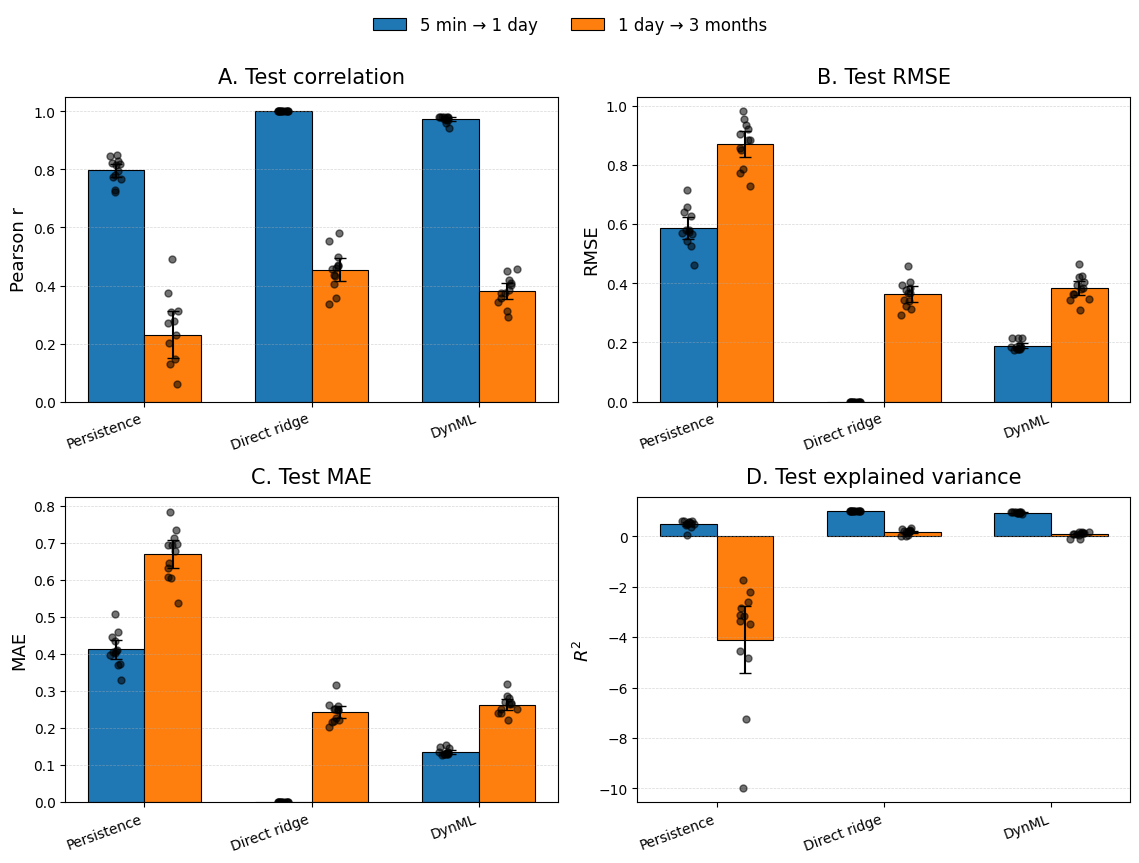

Saved:
liver_leave_one_patient_out_validation.jpeg
liver_leave_one_patient_out_validation.pdf


In [3]:
# ============================================================
# Plot leave-one-patient-out validation
# ============================================================

results_df = pd.read_csv("liver_leave_one_patient_out_validation.csv")

# Exclude overall if you want transition-specific panels only
plot_df = results_df[results_df["transition"] != "overall"].copy()

model_order = ["Persistence", "Direct ridge", "DynML"]
transition_order = [
    "5 Minutes -> 1 Day",
    "1 Day -> 3 Months"
]

pretty_model = {
    "Persistence": "Persistence",
    "Direct ridge": "Direct ridge",
    "DynML": "DynML"
}

pretty_transition = {
    "5 Minutes -> 1 Day": "5 min → 1 day",
    "1 Day -> 3 Months": "1 day → 3 months"
}

plot_df["model"] = pd.Categorical(
    plot_df["model"],
    categories=model_order,
    ordered=True
)

plot_df["transition"] = pd.Categorical(
    plot_df["transition"],
    categories=transition_order,
    ordered=True
)

summary_plot = (
    plot_df
    .groupby(["transition", "model"], as_index=False)
    .agg(
        mean_pearson_r=("pearson_r", "mean"),
        std_pearson_r=("pearson_r", "std"),
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        mean_mae=("mae", "mean"),
        std_mae=("mae", "std"),
        mean_r2=("r2", "mean"),
        std_r2=("r2", "std"),
        n_patients=("held_out_patient", "nunique")
    )
)

for metric in ["pearson_r", "rmse", "mae", "r2"]:
    summary_plot[f"ci_{metric}"] = (
        1.96 * summary_plot[f"std_{metric}"] / np.sqrt(summary_plot["n_patients"])
    )

metrics = [
    ("mean_pearson_r", "ci_pearson_r", "Pearson r", "A. Test correlation"),
    ("mean_rmse", "ci_rmse", "RMSE", "B. Test RMSE"),
    ("mean_mae", "ci_mae", "MAE", "C. Test MAE"),
    ("mean_r2", "ci_r2", r"$R^2$", "D. Test explained variance")
]

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.5))
axes = axes.flatten()

x = np.arange(len(model_order))
width = 0.34

for ax, (mean_col, ci_col, ylabel, title) in zip(axes, metrics):

    for j, transition in enumerate(transition_order):
        df_t = (
            summary_plot[summary_plot["transition"] == transition]
            .sort_values("model")
        )

        offset = (j - 0.5) * width

        ax.bar(
            x + offset,
            df_t[mean_col].values,
            width=width,
            yerr=df_t[ci_col].values,
            capsize=4,
            edgecolor="black",
            linewidth=0.8,
            label=pretty_transition[transition]
        )

        # Overlay held-out patient points
        for k, model_name in enumerate(model_order):
            vals = plot_df[
                (plot_df["transition"] == transition)
                & (plot_df["model"] == model_name)
            ][mean_col.replace("mean_", "")].values

            jitter = np.random.default_rng(123 + j + k).normal(
                0,
                0.025,
                size=len(vals)
            )

            ax.scatter(
                np.full(len(vals), x[k] + offset) + jitter,
                vals,
                s=25,
                color="black",
                alpha=0.55,
                zorder=3
            )

    ax.set_title(title, fontsize=15, pad=10)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([pretty_model[m] for m in model_order], rotation=20, ha="right")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

axes[0].set_ylim(0, 1.05)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    frameon=False,
    fontsize=12,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "liver_leave_one_patient_out_validation.jpeg",
    dpi=900,
    bbox_inches="tight"
)

plt.savefig(
    "liver_leave_one_patient_out_validation.pdf",
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("liver_leave_one_patient_out_validation.jpeg")
print("liver_leave_one_patient_out_validation.pdf")